# Phase 1 — Shared Data Preparation
**VizWiz-Captions | Deep Learning AT3**

Run this notebook **once as a group** on Google Colab. It covers:

1. EDA — Explore dataset structure and statistics
2. Clean & tokenise captions
3. Build vocabulary (word2idx / idx2word)
4. Create train / val / test splits (fixed seed)
5. Implement VizWizDataset class & DataLoader with collate_fn
6. Verify end-to-end data pipeline (test batch)

**Data flow:** Downloads VizWiz to Colab's local `/content/data/raw/` (fast I/O during processing), then exports all artefacts to the shared Google Drive folder `AT3-DL-ImageCaptioning/processed/`. Team members mount Drive in their own notebooks — no re-downloading needed.

## 0. Install dependencies

In [30]:
!pip install torch torchvision tqdm nltk pandas Pillow matplotlib

## 1. Imports, paths & reproducibility

In [31]:
from google.colab import drive
drive.mount('/content/drive')

import json
import random
import pickle
import string
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from tqdm.auto import tqdm

import nltk
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Special token indices ─────────────────────────────────────────────────────
PAD_IDX, SOS_IDX, EOS_IDX, UNK_IDX = 0, 1, 2, 3
SPECIAL_TOKENS = ['<PAD>', '<SOS>', '<EOS>', '<UNK>']

# ── Paths ─────────────────────────────────────────────────────────────────────
# Colab local workspace — fast I/O during processing (ephemeral, lost on disconnect)
RAW_DIR       = Path('/content/data/raw')
PROCESSED_DIR = Path('/content/data/processed')

# Shared Google Drive — persistent, accessible by all team members
DRIVE_PROCESSED = Path('/content/drive/MyDrive/AT3-DL-ImageCaptioning/processed')

for p in [RAW_DIR, PROCESSED_DIR, DRIVE_PROCESSED]:
    p.mkdir(parents=True, exist_ok=True)

print('PyTorch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
print('Drive writable:', DRIVE_PROCESSED.exists())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PyTorch: 2.10.0+cpu
CUDA available: False
Drive writable: True


## 2. Locate raw data

In [32]:
# ── Download images if not already present ────────────────────────────────────
if not any(RAW_DIR.rglob('*.jpg')):
    !wget -q --show-progress https://vizwiz.cs.colorado.edu/VizWiz_final/images/val.zip \
          -O /content/data/raw/val.zip
    !unzip -q /content/data/raw/val.zip -d /content/data/raw/
    !rm /content/data/raw/val.zip
    print('Images downloaded and extracted.')
else:
    print('Images already present — skipping download.')

jpg_files = list(RAW_DIR.rglob('*.jpg'))
IMG_DIR   = jpg_files[0].parent
print(f'Images found : {len(jpg_files):,}  (in {IMG_DIR})')

# ── Download annotations if not already present ───────────────────────────────
if not any(RAW_DIR.rglob('*.json')):
    !wget -q --show-progress https://vizwiz.cs.colorado.edu/VizWiz_final/caption/annotations.zip \
          -O /content/data/raw/annotations.zip
    !unzip -q /content/data/raw/annotations.zip -d /content/data/raw/
    !rm /content/data/raw/annotations.zip
    print('Annotations downloaded and extracted.')
else:
    print('Annotations already present — skipping download.')

# Prefer val.json — train.json references VizWiz_train_* files not in the val zip
all_jsons  = list(RAW_DIR.rglob('*.json'))
val_jsons  = [f for f in all_jsons if f.stem == 'val']
ANNOT_FILE = val_jsons[0] if val_jsons else all_jsons[0]
print(f'Annotation file: {ANNOT_FILE}')

with open(ANNOT_FILE) as f:
    raw_data = json.load(f)

print('Top-level keys  :', list(raw_data.keys()))
print('Sample image    :', raw_data['images'][0])
print('Sample annotation:', raw_data['annotations'][0])

Images already present — skipping download.
Images found : 7,750  (in /content/data/raw/val)
Annotations already present — skipping download.
Annotation file: /content/data/raw/annotations/val.json
Top-level keys  : ['info', 'images', 'annotations']
Sample image    : {'file_name': 'VizWiz_val_00000000.jpg', 'vizwiz_url': 'https://ivc.ischool.utexas.edu/VizWiz_visualization_img/VizWiz_val_00000000.jpg', 'id': 23431, 'text_detected': True}
Sample annotation: {'caption': 'A computer screen shows a repair prompt on the screen.', 'image_id': 23431, 'is_precanned': False, 'is_rejected': False, 'id': 117155, 'text_detected': True}


## 3. Build DataFrame

In [33]:
images_meta = {img['id']: img['file_name'] for img in raw_data['images']}

records = []
for ann in raw_data['annotations']:
    records.append({
        'image_id':  ann['image_id'],
        'file_name': images_meta[ann['image_id']],
        'caption':   ann['caption'],
    })

df = pd.DataFrame(records)
print(f'Total caption rows : {len(df):,}')
print(f'Unique images      : {df["image_id"].nunique():,}')
df.head()

Total caption rows : 38,750
Unique images      : 7,750


,image_id,file_name,caption
0,23431,VizWiz_val_00000000.jpg,A computer screen shows a repair prompt on the...
1,23431,VizWiz_val_00000000.jpg,a computer screen with a repair automatically ...
2,23431,VizWiz_val_00000000.jpg,partial computer screen showing the need of re...
3,23431,VizWiz_val_00000000.jpg,Part of a computer monitor showing a computer ...
4,23431,VizWiz_val_00000000.jpg,The top of a laptop with a blue background and...


## 4. EDA — Explore dataset structure and statistics

════════════════════════════════════════════════════════════
1. JSON STRUCTURE
════════════════════════════════════════════════════════════
  Top-level keys : ['info', 'images', 'annotations']
  Total images   : 7,750
  Total ann.     : 38,750
  Sample image entry:
    {'file_name': 'VizWiz_val_00000000.jpg', 'vizwiz_url': 'https://ivc.ischool.utexas.edu/VizWiz_visualization_img/VizWiz_val_00000000.jpg', 'id': 23431, 'text_detected': True}
  Sample annotation:
    {'caption': 'A computer screen shows a repair prompt on the screen.', 'image_id': 23431, 'is_precanned': False, 'is_rejected': False, 'id': 117155, 'text_detected': True}

════════════════════════════════════════════════════════════
2. CAPTIONS PER IMAGE
════════════════════════════════════════════════════════════
    5 captions/image : 7,750 images ← expected

════════════════════════════════════════════════════════════
3. CAPTION LENGTH STATS (before cleaning)
════════════════════════════════════════════════════════════
  M

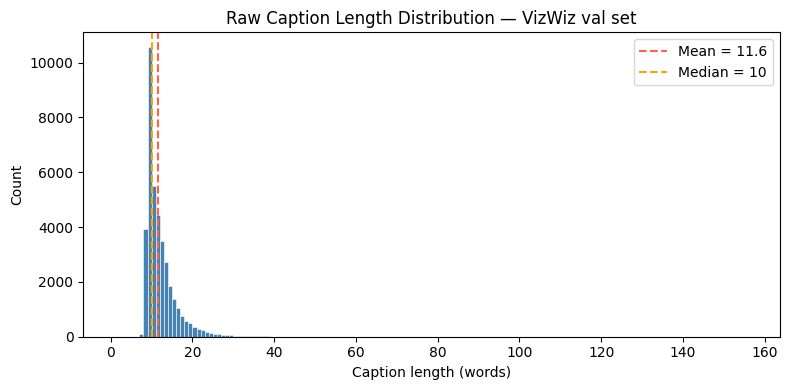


════════════════════════════════════════════════════════════
4. VIZWIZ-SPECIFIC ANOMALIES
════════════════════════════════════════════════════════════
  Literal "unanswerable" captions : 0
  is_rejected == True             : 964

════════════════════════════════════════════════════════════
5. SAMPLE IMAGES (10 random)
════════════════════════════════════════════════════════════


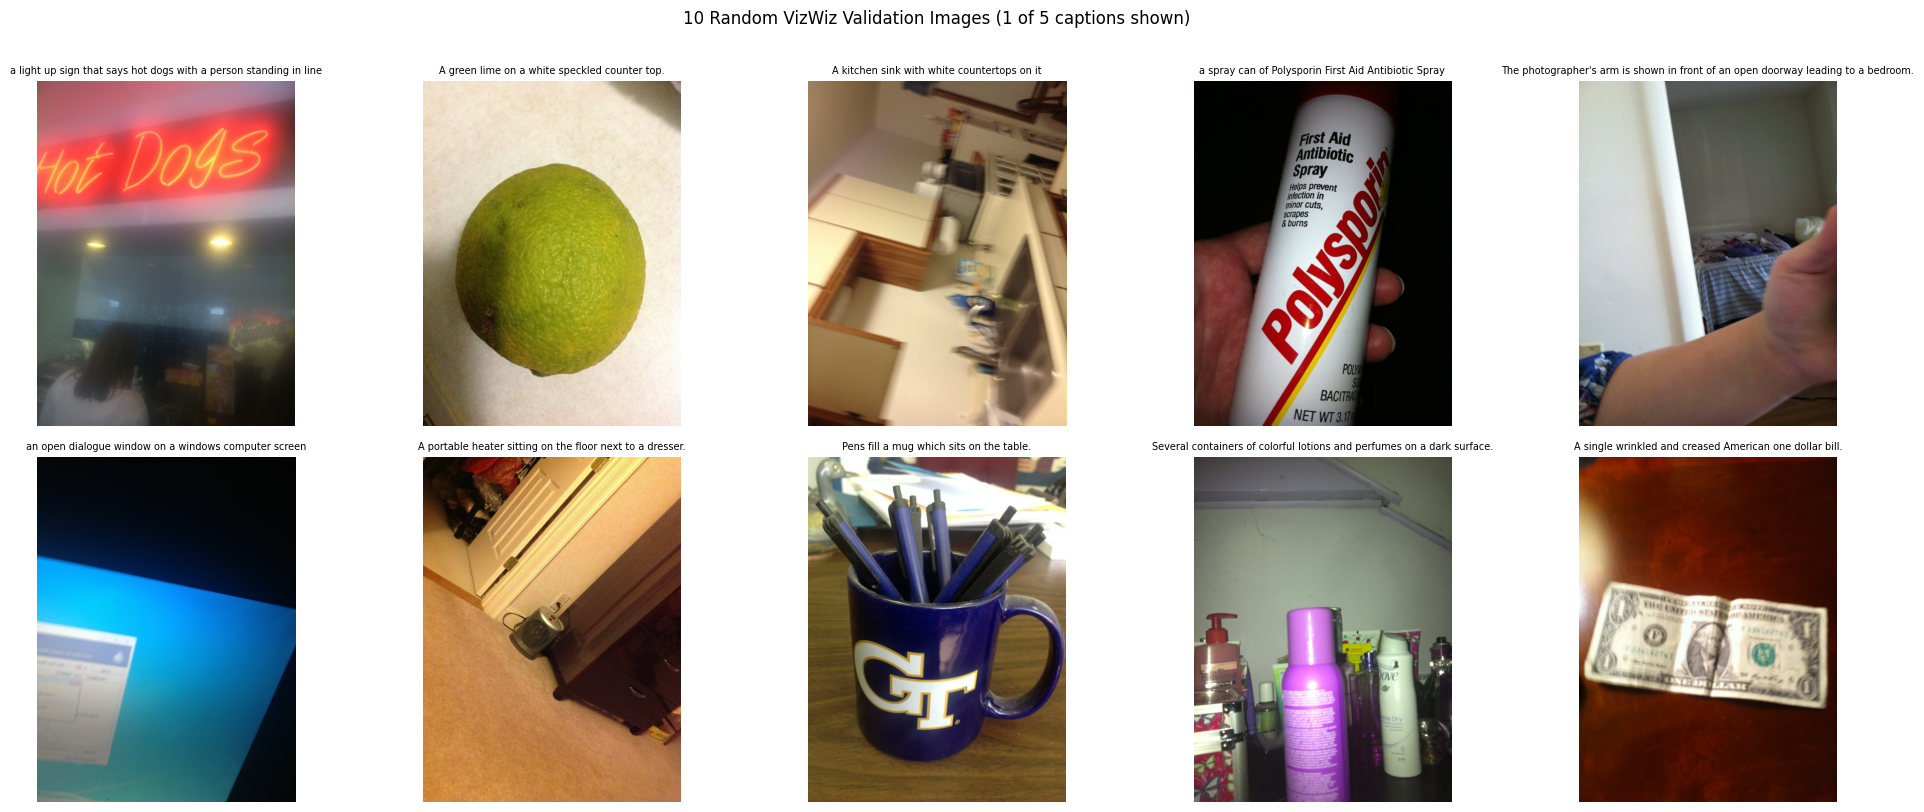

In [34]:
def explore_dataset(df, raw_data):
    print('═' * 60)
    print('1. JSON STRUCTURE')
    print('═' * 60)
    print(f'  Top-level keys : {list(raw_data.keys())}')
    print(f'  Total images   : {len(raw_data["images"]):,}')
    print(f'  Total ann.     : {len(raw_data["annotations"]):,}')
    print(f'  Sample image entry:\n    {raw_data["images"][0]}')
    print(f'  Sample annotation:\n    {raw_data["annotations"][0]}')

    print('\n' + '═' * 60)
    print('2. CAPTIONS PER IMAGE')
    print('═' * 60)
    caps_per_image = df.groupby('image_id').size()
    for n_caps, n_imgs in caps_per_image.value_counts().sort_index().items():
        marker = ' ← expected' if n_caps == 5 else ''
        print(f'    {n_caps} captions/image : {n_imgs:,} images{marker}')

    print('\n' + '═' * 60)
    print('3. CAPTION LENGTH STATS (before cleaning)')
    print('═' * 60)
    word_counts = df['caption'].str.split().map(len)
    print(f'  Mean   : {word_counts.mean():.1f}')
    print(f'  Median : {word_counts.median():.0f}')
    print(f'  Min    : {word_counts.min()}  |  Max: {word_counts.max()}')
    all_words = [w.lower() for cap in df['caption'].str.split() for w in cap]
    print(f'  Raw vocab size : {len(set(all_words)):,}')

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(word_counts, bins=range(1, word_counts.max() + 2),
            color='steelblue', edgecolor='white', linewidth=0.4)
    ax.axvline(word_counts.mean(),   color='tomato', linestyle='--',
               label=f'Mean = {word_counts.mean():.1f}')
    ax.axvline(word_counts.median(), color='orange', linestyle='--',
               label=f'Median = {word_counts.median():.0f}')
    ax.set_xlabel('Caption length (words)')
    ax.set_ylabel('Count')
    ax.set_title('Raw Caption Length Distribution — VizWiz val set')
    ax.legend()
    plt.tight_layout()
    plt.show()

    print('\n' + '═' * 60)
    print('4. VIZWIZ-SPECIFIC ANOMALIES')
    print('═' * 60)
    n_unanswerable = df['caption'].str.strip().str.lower().eq('unanswerable').sum()
    n_rejected = sum(ann.get('is_rejected', False) for ann in raw_data['annotations'])
    print(f'  Literal "unanswerable" captions : {n_unanswerable:,}')
    print(f'  is_rejected == True             : {n_rejected:,}')

    print('\n' + '═' * 60)
    print('5. SAMPLE IMAGES (10 random)')
    print('═' * 60)
    sample_ids = df['image_id'].drop_duplicates().sample(10, random_state=SEED).tolist()
    fig, axes  = plt.subplots(2, 5, figsize=(20, 8))
    for ax, img_id in zip(axes.flat, sample_ids):
        img  = Image.open(IMG_DIR / images_meta[img_id]).convert('RGB')
        caps = df[df['image_id'] == img_id]['caption'].tolist()
        ax.imshow(img)
        ax.set_title(caps[0], fontsize=7, wrap=True)
        ax.axis('off')
    plt.suptitle('10 Random VizWiz Validation Images (1 of 5 captions shown)', y=1.01)
    plt.tight_layout()
    plt.show()


explore_dataset(df, raw_data)

## 5. Clean & tokenise captions

In [35]:
def clean_caption(text: str) -> list:
    text = text.lower().strip()
    text = text.translate(str.maketrans('', '', string.punctuation))
    return nltk.word_tokenize(text)

df['tokens'] = df['caption'].apply(clean_caption)

before = len(df)
df = df[df['tokens'].map(len) > 0].copy()
print(f'Removed {before - len(df)} empty captions')
df[['caption', 'tokens']].head(3)

Removed 0 empty captions


,caption,tokens
0,A computer screen shows a repair prompt on the...,"[a, computer, screen, shows, a, repair, prompt..."
1,a computer screen with a repair automatically ...,"[a, computer, screen, with, a, repair, automat..."
2,partial computer screen showing the need of re...,"[partial, computer, screen, showing, the, need..."


In [36]:
# Filter is_rejected and 'unanswerable'
rejected_keys = {
    (ann['image_id'], ann['caption'])
    for ann in raw_data['annotations']
    if ann.get('is_rejected', False)
}
before = len(df)
mask_rejected     = df.apply(lambda r: (r['image_id'], r['caption']) in rejected_keys, axis=1)
mask_unanswerable = df['caption'].str.strip().str.lower() == 'unanswerable'
df = df[~(mask_rejected | mask_unanswerable)].copy()
print(f'Removed {before - len(df):,} rejected / unanswerable captions')

# Filter by length
MIN_LEN, MAX_LEN = 3, 50
before    = len(df)
token_len = df['tokens'].map(len)
df        = df[(token_len >= MIN_LEN) & (token_len <= MAX_LEN)].copy()
print(f'Removed {before - len(df):,} too-short or too-long captions')

# Filter stopword-only captions
stop_words = set(stopwords.words('english'))
before     = len(df)
mask       = df['tokens'].apply(lambda t: all(w in stop_words for w in t))
df         = df[~mask].copy()
print(f'Removed {before - len(df):,} stopword-only captions')

print(f'\nFinal: {len(df):,} captions | {df["image_id"].nunique():,} unique images')

Removed 1,227 rejected / unanswerable captions
Removed 17 too-short or too-long captions
Removed 0 stopword-only captions

Final: 37,506 captions | 7,727 unique images


## 6. Build vocabulary

In [37]:
FREQ_THRESHOLD = 5

all_tokens  = [tok for tokens in df['tokens'] for tok in tokens]
freq        = Counter(all_tokens)
vocab_words = sorted([w for w, c in freq.items() if c >= FREQ_THRESHOLD])

word2idx = {tok: idx for idx, tok in enumerate(SPECIAL_TOKENS)}
for word in vocab_words:
    word2idx[word] = len(word2idx)
idx2word = {idx: word for word, idx in word2idx.items()}

vocab = {
    'word2idx':       word2idx,
    'idx2word':       idx2word,
    'freq_threshold': FREQ_THRESHOLD,
    'special_tokens': SPECIAL_TOKENS,
    'PAD_IDX': PAD_IDX, 'SOS_IDX': SOS_IDX,
    'EOS_IDX': EOS_IDX, 'UNK_IDX': UNK_IDX,
}

print(f'Vocabulary size : {len(word2idx):,}')
print(f'Sample entries  : { {k: word2idx[k] for k in list(word2idx)[:8]} }')

Vocabulary size : 3,965
Sample entries  : {'<PAD>': 0, '<SOS>': 1, '<EOS>': 2, '<UNK>': 3, '0': 4, '07': 5, '1': 6, '10': 7}


## 7. Train / val / test splits (image-level, fixed seed)

In [38]:
image_ids = df['image_id'].drop_duplicates().tolist()
random.shuffle(image_ids)   # SEED set at top

n       = len(image_ids)
n_train = int(0.8 * n)
n_val   = int(0.1 * n)

splits = {
    'train': image_ids[:n_train],
    'val':   image_ids[n_train : n_train + n_val],
    'test':  image_ids[n_train + n_val :],
}

print(f'Train : {len(splits["train"]):,} images')
print(f'Val   : {len(splits["val"]):,} images')
print(f'Test  : {len(splits["test"]):,} images')

Train : 6,181 images
Val   : 772 images
Test  : 774 images


## 8. VizWizDataset & DataLoaders

In [39]:
class VizWizDataset(Dataset):
    """
    One sample = one (image, caption) pair.
    Images with 5 captions → 5 samples.
    Caption tokens are wrapped with <SOS> and <EOS>.
    """

    DEFAULT_TRANSFORM = T.Compose([
        T.Resize((224, 224)),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406],
                    std=[0.229, 0.224, 0.225]),
    ])

    def __init__(self, image_ids, captions_df, id_to_filename,
                 img_dir, word2idx, transform=None):
        self.img_dir   = Path(img_dir)
        self.word2idx  = word2idx
        self.transform = transform or self.DEFAULT_TRANSFORM

        split_df = captions_df[captions_df['image_id'].isin(image_ids)].reset_index(drop=True)

        self.samples = []
        for _, row in split_df.iterrows():
            fname   = id_to_filename[row['image_id']]
            indices = ([SOS_IDX]
                       + [word2idx.get(tok, UNK_IDX) for tok in row['tokens']]
                       + [EOS_IDX])
            self.samples.append((self.img_dir / fname, indices))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, indices = self.samples[idx]
        image   = Image.open(img_path).convert('RGB')
        image   = self.transform(image)
        caption = torch.tensor(indices, dtype=torch.long)
        return image, caption


def collate_fn(batch):
    """Pad variable-length captions within a batch."""
    images, captions = zip(*batch)
    images   = torch.stack(images, dim=0)
    lengths  = torch.tensor([len(c) for c in captions], dtype=torch.long)
    max_len  = lengths.max().item()
    padded   = torch.full((len(captions), max_len), PAD_IDX, dtype=torch.long)
    for i, cap in enumerate(captions):
        padded[i, :len(cap)] = cap
    return images, padded, lengths


print('VizWizDataset and collate_fn defined.')

VizWizDataset and collate_fn defined.


In [40]:
BATCH_SIZE = 32

id_to_filename = (
    df[['image_id', 'file_name']]
    .drop_duplicates()
    .set_index('image_id')['file_name']
    .to_dict()
)

train_transform = T.Compose([
    T.Resize((256, 256)),
    T.RandomCrop(224),
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_dataset = VizWizDataset(splits['train'], df, id_to_filename, IMG_DIR, word2idx, train_transform)
val_dataset   = VizWizDataset(splits['val'],   df, id_to_filename, IMG_DIR, word2idx)
test_dataset  = VizWizDataset(splits['test'],  df, id_to_filename, IMG_DIR, word2idx)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, collate_fn=collate_fn, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, collate_fn=collate_fn, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, collate_fn=collate_fn)

print(f'Train : {len(train_dataset):,} samples | {len(train_loader):,} batches')
print(f'Val   : {len(val_dataset):,} samples | {len(val_loader):,} batches')
print(f'Test  : {len(test_dataset):,} samples | {len(test_loader):,} batches')

Train : 29,997 samples | 938 batches
Val   : 3,758 samples | 118 batches
Test  : 3,751 samples | 118 batches


## 9. Verify end-to-end data pipeline (test batch)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


=== Pipeline verification (train) ===
images.shape   : (32, 3, 224, 224)   ← expected (B, 3, 224, 224)
captions.shape : (32, 34)  ← expected (B, max_seq_len)
lengths        : [11, 11, 15, 11, 17, 10] ...
Decoded [0]    : "a piece of computer hardware that is still labeled"
✓ No PAD tokens before stated length in first 4 samples.


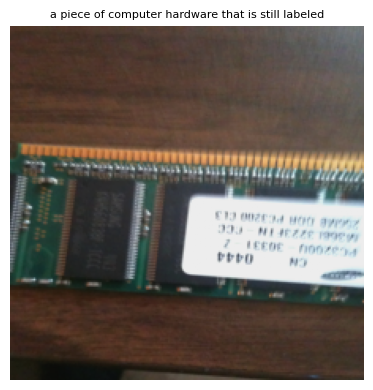

=== Done ===


In [41]:
def verify_pipeline(loader, idx2word, split_name='train'):
    images, captions, lengths = next(iter(loader))

    print(f'=== Pipeline verification ({split_name}) ===')
    print(f'images.shape   : {tuple(images.shape)}   ← expected (B, 3, 224, 224)')
    print(f'captions.shape : {tuple(captions.shape)}  ← expected (B, max_seq_len)')
    print(f'lengths        : {lengths[:6].tolist()} ...')

    # Decode first caption
    words = []
    for idx in captions[0].tolist():
        if idx == EOS_IDX:
            break
        if idx not in (PAD_IDX, SOS_IDX):
            words.append(idx2word.get(idx, '<UNK>'))
    print(f'Decoded [0]    : "{" ".join(words)}"')

    # Sanity check: no PAD before stated length
    for i in range(min(4, len(captions))):
        assert PAD_IDX not in captions[i, :lengths[i]].tolist(), \
            f'PAD found before stated length in sample {i}!'
    print('✓ No PAD tokens before stated length in first 4 samples.')

    # Display first image (undo normalisation)
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img_show = (images[0] * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(img_show)
    ax.set_title(' '.join(words), fontsize=8, wrap=True)
    ax.axis('off')
    plt.tight_layout()
    plt.show()
    print('=== Done ===')


verify_pipeline(train_loader, idx2word, 'train')

## 10. Export processed artefacts to Google Drive

Saves `vocab.pkl`, `splits.json`, and `captions_clean.json` to the shared Drive folder.  
Team members can then mount Drive in their individual notebooks and load these directly — no re-processing needed.

In [42]:
import shutil

# ── Build captions_clean dict ─────────────────────────────────────────────────
captions_clean  = defaultdict(list)
id_to_fname_str = (
    df[['image_id', 'file_name']]
    .drop_duplicates()
    .set_index('image_id')['file_name']
    .to_dict()
)
for _, row in df.iterrows():
    captions_clean[str(row['image_id'])].append(row['tokens'])

captions_clean_payload = {
    'captions':       dict(captions_clean),
    'id_to_filename': {str(k): v for k, v in id_to_fname_str.items()},
}

# ── Save locally first (fast), then copy to Drive ─────────────────────────────
artefacts = {
    'vocab.pkl':           ('wb', lambda f: pickle.dump(vocab, f)),
    'splits.json':         ('w',  lambda f: json.dump(splits, f)),
    'captions_clean.json': ('w',  lambda f: json.dump(captions_clean_payload, f)),
}

for filename, (mode, writer) in artefacts.items():
    local_path = PROCESSED_DIR / filename
    drive_path = DRIVE_PROCESSED / filename
    with open(local_path, mode) as f:
        writer(f)
    shutil.copy(local_path, drive_path)
    size_kb = drive_path.stat().st_size / 1024
    print(f'  ✓ {filename}  ({size_kb:.1f} KB)  → Drive')

print()
print('=== Drive artefacts ===')
for p in sorted(DRIVE_PROCESSED.iterdir()):
    print(f'  {p.name}  ({p.stat().st_size / 1024:.1f} KB)')

  ✓ vocab.pkl  (76.8 KB)  → Drive
  ✓ splits.json  (52.9 KB)  → Drive
  ✓ captions_clean.json  (3975.6 KB)  → Drive

=== Drive artefacts ===
  captions_clean.json  (3975.6 KB)
  images_224  (4.0 KB)
  splits.json  (52.9 KB)
  vocab.pkl  (76.8 KB)


## 11. Copy images to Google Drive

Copies all 7,750 `.jpg` files from the Colab local workspace to `processed/images_224/` on Drive.  
This step is slow (~5–10 min) but only needs to run once. Student notebooks load images directly from this folder.

In [43]:
DRIVE_IMAGES = DRIVE_PROCESSED / 'images_224'
DRIVE_IMAGES.mkdir(parents=True, exist_ok=True)

jpg_files     = list(IMG_DIR.glob('*.jpg'))
already_there = len(list(DRIVE_IMAGES.glob('*.jpg')))
to_copy       = [f for f in jpg_files if not (DRIVE_IMAGES / f.name).exists()]

print(f'Total images     : {len(jpg_files):,}')
print(f'Already on Drive : {already_there:,}')
print(f'To copy          : {len(to_copy):,}')

for src in tqdm(to_copy, desc='Copying images to Drive'):
    shutil.copy(src, DRIVE_IMAGES / src.name)

n_on_drive = len(list(DRIVE_IMAGES.glob('*.jpg')))
print(f'\n✓ images_224/ on Drive : {n_on_drive:,} images')

Total images     : 7,750
Already on Drive : 0
To copy          : 7,750


Copying images to Drive:   0%|          | 0/7750 [00:00<?, ?it/s]


✓ images_224/ on Drive : 7,750 images
